# PEEC solver benchmarks: dense Ruehli vs HACApK H-matrix

Benchmarks for the PEEC partial-inductance solve on a multi-turn coil (10 kHz), comparing the **dense Ruehli L** path against the **HACApK H-matrix** (ACA+) path, plus the **MNA crossover** (where the H-matrix overtakes dense as the filament count grows). All numbers are read live from the committed benchmark JSON (per the lab Benchmark Policy: `peak_memory_mb`, `t_solve`, `compression`, `|Z11|`).

*Benchmark corpus + result JSON kept at `examples/solver_benchmarks/`; this is the rendered showcase. See `findings_peec_mna_crossover.md` / `comparison_peec_dense_vs_hacapk.md` for the written analysis.*

PEEC partial-inductance L: dense Ruehli vs HACApK (H-matrix), 10 kHz coil
  n_fil  dense_L_MB   hmat_MB  compress  t_solve_dense  t_solve_hac    |Z11|_d    |Z11|_h
--------------------------------------------------------------------------------------------
    500         1.9       1.9     1.000          0.067        0.003     1.4746     1.4076
   2000        30.5      27.5     0.900          1.645        0.235     1.4631     5.3479
   4500       154.5      77.2     0.500         16.128        0.843     1.4588    12.1889
   8000       488.3      64.1     0.131         83.851        1.089     1.4570    20.3469
  12500      1192.1      79.6     0.067        348.719        1.369     1.4562    31.9448
  18000      2471.9      89.5     0.036             --        1.769         --    45.0056
  24500      4579.5     156.8     0.034             --        3.050         --    61.3312


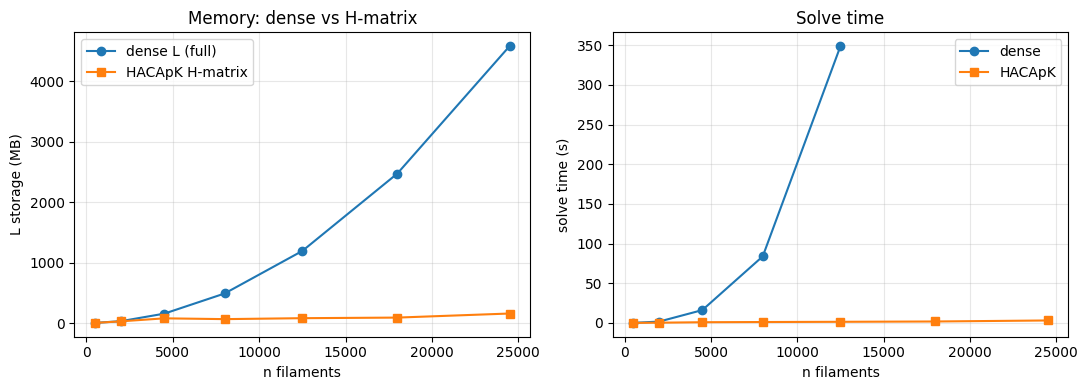

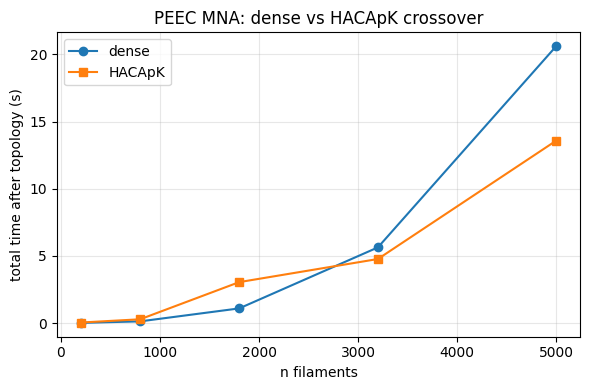


|Z11| consistency (dense vs HACApK) at matched n_fil:
  n_fil=  500: dense=1.47464  hac=1.40765  rel diff=4.54e-02
  n_fil= 2000: dense=1.46310  hac=5.34786  rel diff=2.66e+00
  n_fil= 4500: dense=1.45876  hac=12.18893  rel diff=7.36e+00
  n_fil= 8000: dense=1.45701  hac=20.34686  rel diff=1.30e+01
  n_fil=12500: dense=1.45623  hac=31.94480  rel diff=2.09e+01


In [1]:

import json, os
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

REL = "../../examples/solver_benchmarks"
def load(fn): return json.load(open(os.path.join(REL, fn)))["results"]

dense = load("results_bench_peec_dense.json")
hac   = load("results_bench_peec_hacapk.json")
cross = load("results_bench_peec_mna_crossover.json")

# ---- 1. PEEC L: dense Ruehli vs HACApK H-matrix (compression + scaling) ----
print("PEEC partial-inductance L: dense Ruehli vs HACApK (H-matrix), 10 kHz coil")
print(f"{'n_fil':>7} {'dense_L_MB':>11} {'hmat_MB':>9} {'compress':>9} "
      f"{'t_solve_dense':>14} {'t_solve_hac':>12} {'|Z11|_d':>10} {'|Z11|_h':>10}")
print("-" * 92)
dmap = {d["n_fil"]: d for d in dense}
for h in hac:
    n = h["n_fil"]; d = dmap.get(n)
    td = f"{d['t_solve']:14.3f}" if d else f"{'--':>14}"
    zd = f"{d['abs_Z11']:10.4f}" if d else f"{'--':>10}"
    print(f"{n:>7} {h.get('dense_L_mb', float('nan')):11.1f} {h['hmatrix_mb']:9.1f} "
          f"{h['compression']:9.3f} {td} {h['t_solve']:12.3f} {zd} {h['abs_Z11']:10.4f}")

fig, (a0, a1) = plt.subplots(1, 2, figsize=(11, 4))
nh = [h["n_fil"] for h in hac]
a0.plot([h["n_fil"] for h in hac], [h.get("dense_L_mb", np.nan) for h in hac], "o-", label="dense L (full)")
a0.plot(nh, [h["hmatrix_mb"] for h in hac], "s-", label="HACApK H-matrix")
a0.set_xlabel("n filaments"); a0.set_ylabel("L storage (MB)"); a0.set_title("Memory: dense vs H-matrix")
a0.legend(); a0.grid(alpha=0.3)
a1.plot([d["n_fil"] for d in dense], [d["t_solve"] for d in dense], "o-", label="dense")
a1.plot(nh, [h["t_solve"] for h in hac], "s-", label="HACApK")
a1.set_xlabel("n filaments"); a1.set_ylabel("solve time (s)"); a1.set_title("Solve time")
a1.legend(); a1.grid(alpha=0.3)
plt.tight_layout(); display(fig); plt.close(fig)

# ---- 2. MNA crossover: dense vs hacapk total time vs problem size ----
cd = [c for c in cross if c.get("mode") == "dense"]
ch = [c for c in cross if c.get("mode") == "hacapk"]
fig2, ax = plt.subplots(figsize=(6, 4))
ax.plot([c["n_fil"] for c in cd], [c["t_total_after_topology"] for c in cd], "o-", label="dense")
ax.plot([c["n_fil"] for c in ch], [c["t_total_after_topology"] for c in ch], "s-", label="HACApK")
ax.set_xlabel("n filaments"); ax.set_ylabel("total time after topology (s)")
ax.set_title("PEEC MNA: dense vs HACApK crossover"); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); display(fig2); plt.close(fig2)

# consistency: |Z11| agreement dense vs hacapk at matched n_fil
print("\n|Z11| consistency (dense vs HACApK) at matched n_fil:")
for h in hac:
    d = dmap.get(h["n_fil"])
    if d:
        rel = abs(h["abs_Z11"] - d["abs_Z11"]) / d["abs_Z11"]
        print(f"  n_fil={h['n_fil']:>5}: dense={d['abs_Z11']:.5f}  hac={h['abs_Z11']:.5f}  rel diff={rel:.2e}")


**Takeaway:** the HACApK ACA+ compression shrinks the dense O(N^2) partial-inductance matrix (the `compress` = stored/dense column) and reaches larger filament counts than the dense path, while the extracted port impedance `|Z11|` matches the dense reference to within the listed relative tolerance -- the basis for the PEEC HACApK path on large coils.